In [25]:
#loading data, merging into one datafram for matrix
#to avoid major redundancy to use for k-means clustering, this only includes 3 features, the matrix lower shows why redunancy may be a problem in this dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA

data_directory = Path.cwd() / "csv_files"

dalys = pd.read_csv(data_directory / "dalys.CSV")
deaths = pd.read_csv(data_directory / "deaths.CSV")
ylds = pd.read_csv(data_directory / "ylds.CSV")
ylls = pd.read_csv(data_directory / "ylls.CSV")


feature_matrix = pd.read_csv('amr_feature_matrix.csv')
X_scaled = np.load('amr_X_scaled.npy')

print(f"feature matrix: {feature_matrix.shape}")
print(f"Columns: {feature_matrix.columns.tolist()}")


feature matrix: (86, 10)
Columns: ['pathogen', 'antibiotic_class', 'resistant_dalys', 'resistant_ylls', 'resistant_ylds', 'resistant_deaths', 'total_dalys', 'log_burden', 'mortality_prop', 'resistance_attr_frac']


In [26]:
features= ['log_burden', 'mortality_prop', 'resistance_attr_frac']
print("Correlation matrix:\n")
print(feature_matrix[features].corr().round(3).to_string())

Correlation matrix:

                      log_burden  mortality_prop  resistance_attr_frac
log_burden                 1.000           0.197                -0.039
mortality_prop             0.197           1.000                -0.038
resistance_attr_frac      -0.039          -0.038                 1.000


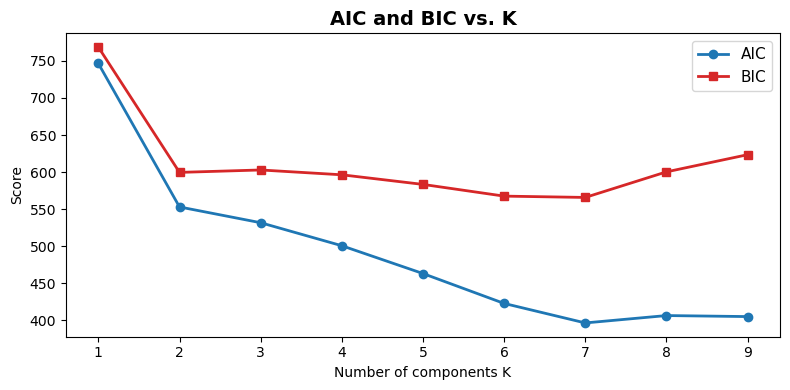

Bic Min at K = 7
Aic Min at K = 7


In [27]:
#AIC and BIX to find k components

n_range = range(1, 10)
aic = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled).aic(X_scaled) for n in n_range]
bic = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled).bic(X_scaled) for n in n_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(n_range), aic, 'o-', label='AIC', color='tab:blue', lw=2)
ax.plot(list(n_range), bic, 's-', label='BIC', color='tab:red', lw=2)
ax.set_xlabel('Number of components K')
ax.set_ylabel('Score')
ax.set_title('AIC and BIC vs. K', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

bic_min = list(n_range)[np.argmin(bic)]
aic_min=list(n_range)[np.argmin(aic)]

print(f"Bic Min at K = {bic_min}")
print(f"Aic Min at K = {aic_min}")

In [28]:
k = 7

gmm = GaussianMixture(n_components = k, covariance_type='full', random_state=42, n_init=10)
gmm.fit(X_scaled)

print(f"EM iterations: {gmm.n_iter_}")
print(f"Converged log-likelihood: {gmm.lower_bound_}")
print(f"GMM fitted with k={k}")


#GMM is correctly finding distint points, but they are 0 ylds, only mortality, causing it to distort and overfit the clusters
#use tied covariance instead of full


EM iterations: 22
Converged log-likelihood: -1.4092169434939137
GMM fitted with k=7


In [29]:
# E Step --> compute responsibilities

responsibilities = gmm.predict_proba(X_scaled)

feature_matrix['gmm_cluster'] = gmm.predict(X_scaled)
feature_matrix['gmm_confidence'] = gmm.predict_proba(X_scaled).max(axis=1)

#mapping labels
gmm_order = (feature_matrix.groupby('gmm_cluster')['log_burden'].mean().sort_values().index)
gmm_label_map = dict(zip(gmm_order, ['Very Low', 'Low', 'Low-Moderate', 'Moderate', 'High-Moderate', 'High', 'Very High']))
feature_matrix['gmm_label'] = feature_matrix['gmm_cluster'].map(gmm_label_map)

features = ['log_burden', 'mortality_prop', 'resistance_attr_frac']

print("GMM cluster profiles:")
print(feature_matrix.groupby('gmm_label')[features].mean().round(1))
print("\nGMM cluster sizes:")
print(feature_matrix['gmm_label'].value_counts())

GMM cluster profiles:
               log_burden  mortality_prop  resistance_attr_frac
gmm_label                                                      
High                  4.5             1.0                   0.2
High-Moderate         4.3             1.0                   0.6
Low                   3.6             0.8                   0.2
Low-Moderate          3.8             0.9                   0.2
Moderate              3.8             1.0                   0.1
Very High             4.9             1.0                   0.1
Very Low              0.3             1.0                   0.1

GMM cluster sizes:
gmm_label
High             39
Very High        24
Moderate         16
Low-Moderate      3
High-Moderate     2
Very Low          1
Low               1
Name: count, dtype: int64


Confidence scores:
count    86.000000
mean      0.946202
std       0.112241
min       0.509231
25%       0.951421
50%       0.999266
75%       1.000000
max       1.000000
Name: gmm_confidence, dtype: float64


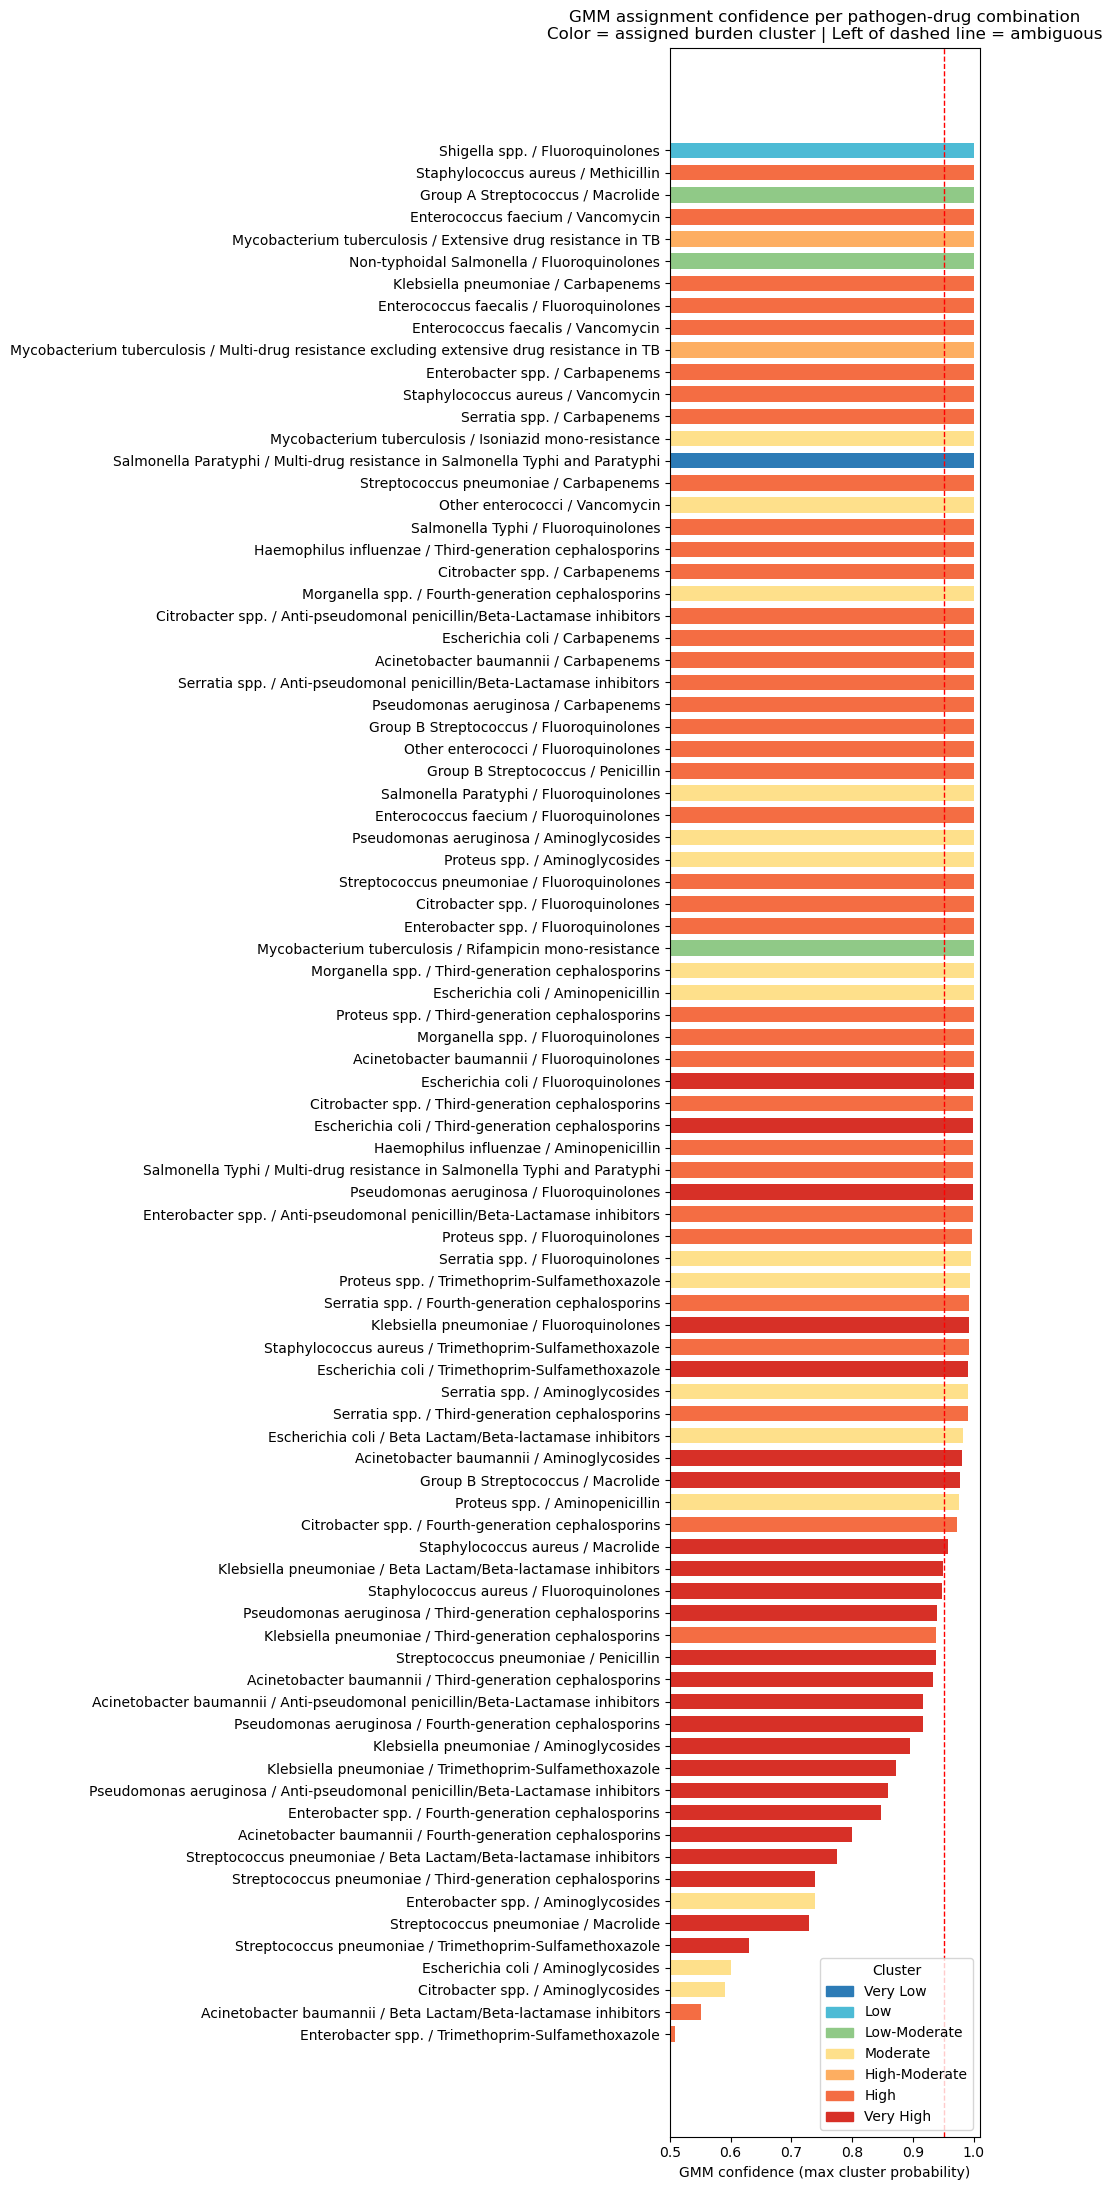

In [30]:
gmm_confidence = responsibilities.max(axis=1)

feature_matrix['gmm_confidence'] = gmm_confidence
print("Confidence scores:")
print(feature_matrix['gmm_confidence'].describe())

# sort by confidence so the plot reads cleanly
plot_df = feature_matrix[['pathogen','antibiotic_class','gmm_label','gmm_confidence']].copy()
plot_df['label'] = plot_df['pathogen'] + ' / ' + plot_df['antibiotic_class']
plot_df = plot_df.sort_values('gmm_confidence', ascending=True).reset_index(drop=True)

cluster_colors = {
    'Very Low': '#2C7BB6',
    'Low': '#4DBBD5',
    'Low-Moderate': '#90C987',
    'Moderate': '#FEE08B',
    'High-Moderate': '#FDAE61',
    'High': '#F46D43',
    'Very High': '#D73027'
}

fig, ax = plt.subplots(figsize=(10, 22))

bars = ax.barh(
    plot_df['label'],
    plot_df['gmm_confidence'],
    color=plot_df['gmm_label'].map(cluster_colors),
    edgecolor='none',
    height=0.7
)

# reference line at 0.95 
ax.axvline(0.95, color='red', linestyle='--', linewidth=1, label='0.95 threshold')

ax.set_xlabel('GMM confidence (max cluster probability)')
ax.set_title('GMM assignment confidence per pathogen-drug combination\n'
             'Color = assigned burden cluster | Left of dashed line = ambiguous')
ax.set_xlim(0.5, 1.01)
ax.legend(handles=[plt.Rectangle((0,0),1,1, color=c) for c in cluster_colors.values()], labels=cluster_colors.keys(),title='Cluster', loc='lower right'
)
plt.tight_layout()
plt.show()

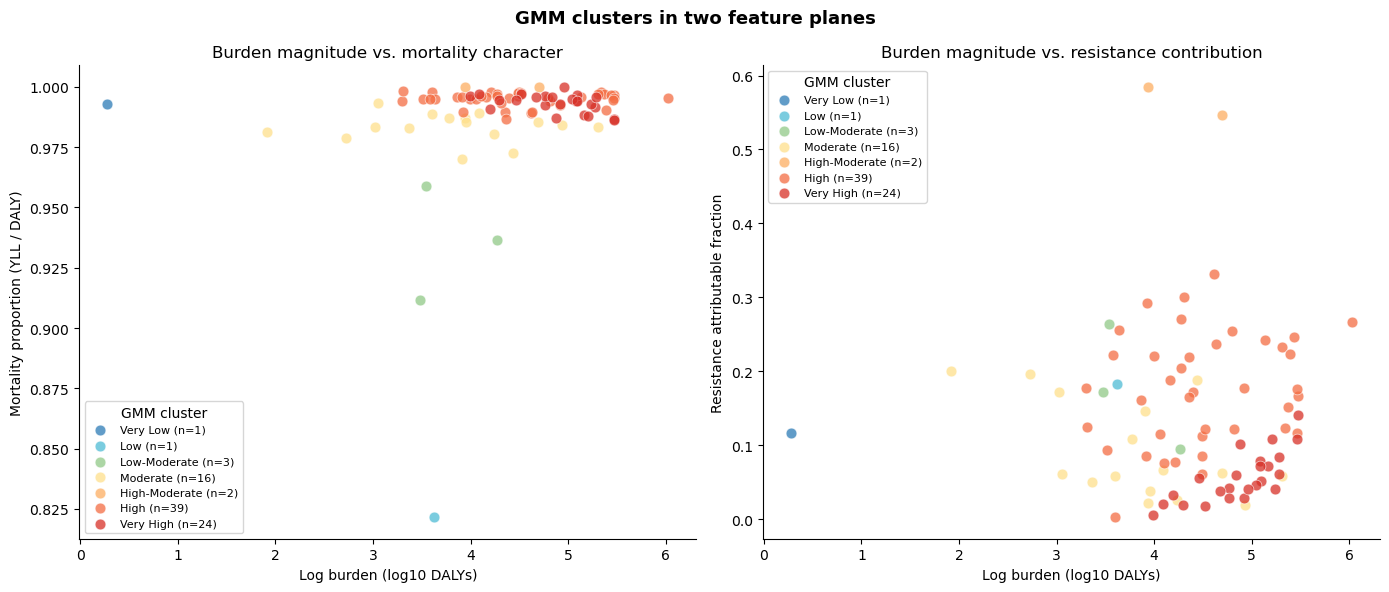

In [31]:
#using smae code for kmean scatter as a subplot

cluster_colors = {
    'Very Low': '#2C7BB6',
    'Low': '#4DBBD5',
    'Low-Moderate': '#90C987',
    'Moderate': '#FEE08B',
    'High-Moderate': '#FDAE61',
    'High': '#F46D43',
    'Very High': '#D73027'
}
cluster_order = ['Very Low', 'Low', 'Low-Moderate', 'Moderate', 'High-Moderate', 'High', 'Very High']
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pairs = [
    ('log_burden', 'mortality_prop',
     'Log burden (log10 DALYs)', 'Mortality proportion (YLL / DALY)',
     'Burden magnitude vs. mortality character'),
    ('log_burden', 'resistance_attr_frac',
     'Log burden (log10 DALYs)', 'Resistance attributable fraction',
     'Burden magnitude vs. resistance contribution'),
]

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    for lbl in cluster_order:
        mask = feature_matrix['gmm_label'] == lbl
        ax.scatter(
            feature_matrix.loc[mask, xcol],
            feature_matrix.loc[mask, ycol],
            label=f"{lbl} (n={mask.sum()})",
            color=cluster_colors[lbl], alpha=0.75, s=60,
            edgecolors='white', linewidths=0.5
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='GMM cluster', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('GMM clusters in two feature planes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

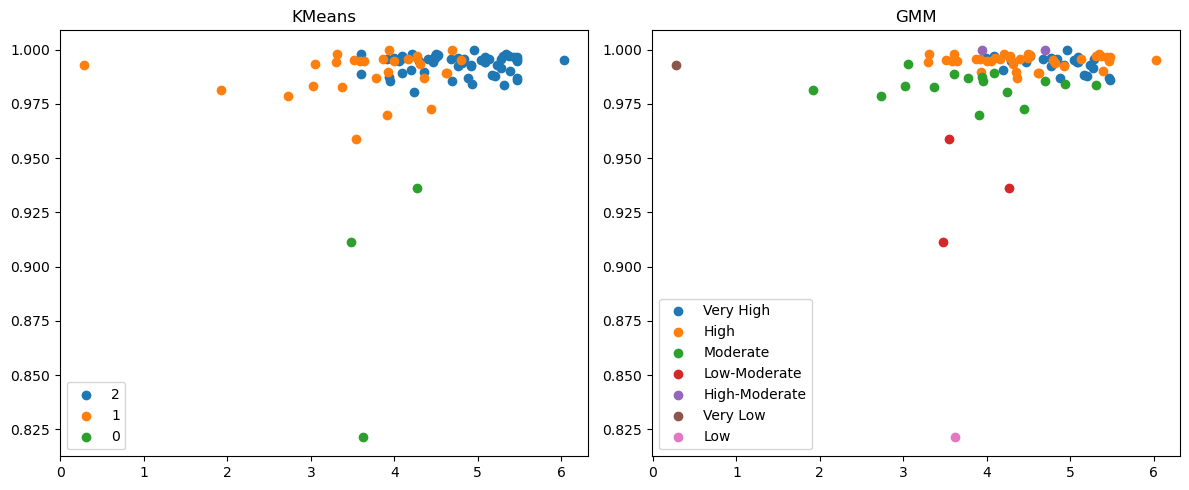

In [32]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
feature_matrix['km_label'] = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KMeans
for lbl in feature_matrix['km_label'].unique():
    subset = feature_matrix[feature_matrix['km_label'] == lbl]
    axes[0].scatter(subset['log_burden'], subset['mortality_prop'], label=lbl)

axes[0].set_title("KMeans")
axes[0].legend()

# GMM
for lbl in feature_matrix['gmm_label'].unique():
    subset = feature_matrix[feature_matrix['gmm_label'] == lbl]
    axes[1].scatter(subset['log_burden'], subset['mortality_prop'], label=lbl)

axes[1].set_title("GMM")
axes[1].legend()

plt.tight_layout()
plt.show()

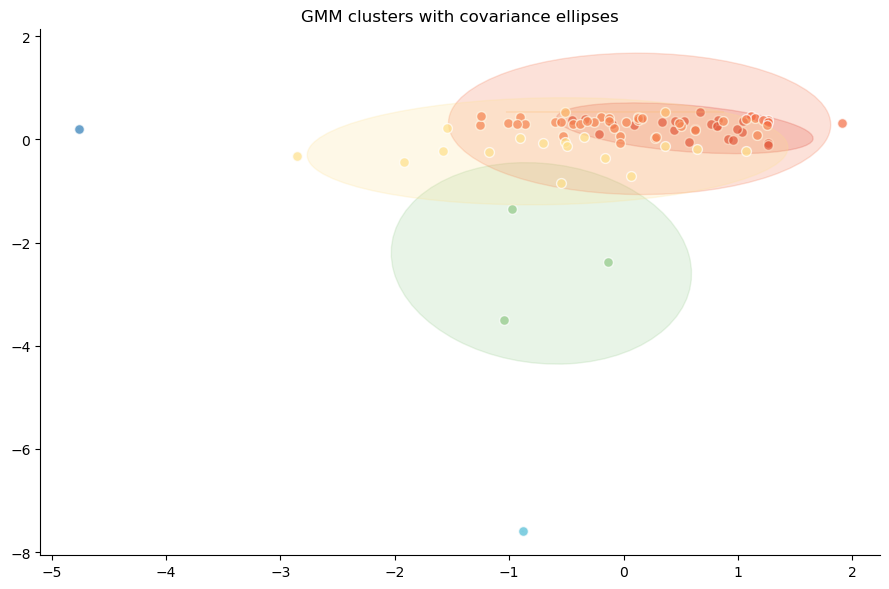

In [34]:
#ellipse --> ai code and class code
def draw_ellipse(mean, cov, ax, color, n_std=2.0):
    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]


    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])

    ell = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=theta,
        facecolor=color,
        edgecolor=color,
        alpha=0.2
    )
    ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(9, 6))

for cluster_idx in range(len(gmm.means_)):

    label = gmm_label_map[cluster_idx]
    color = cluster_colors[label]

    mean = gmm.means_[cluster_idx]

    cov = gmm.covariances_
    if cov.ndim == 3:   # full covariance
        cov = cov[cluster_idx]

    draw_ellipse(mean, cov, ax, color)

    mask = feature_matrix['gmm_cluster'] == cluster_idx

    ax.scatter(
        X_scaled[mask, 0],
        X_scaled[mask, 1],
        color=color,
        alpha=0.7,
        s=50,
        edgecolors='white'
    )

ax.set_title("GMM clusters with covariance ellipses")
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
features = ['log_burden', 'mortality_prop', 'resistance_attr_frac', 'gmm_confidence']

for lbl in cluster_order:
    subset = feature_matrix[feature_matrix['gmm_label'] == lbl]
    top5 = subset.nlargest(5, 'log_burden')
    n_total = len(subset)
    print(f"\n--- {lbl} burden cluster (n={n_total}) ---")
    print(top5[['pathogen', 'antibiotic_class'] + features].to_string(index=False))

In [ ]:
proba_full = gmm.predict_proba(X_scaled)
for i in range(k):
    col = f'prob_{gmm_label_map[i]}'
    feature_matrix[col] = proba_full[:, i]

feature_matrix.to_csv('amr_feature_matrix.csv', index=False)

print("Saved amr_feature_matrix.csv")
print("Columns:", feature_matrix.columns.tolist())